#  Convolutional Neural Networks (CNNs)
## A Detailed Explanation



This notebook is a **comprehensive** reference that takes you from zero to building and training a complete CNN for image classification.

> **What will you learn?**
> - What CNNs are and why we use them instead of ordinary (Fully Connected) networks.
> - The core building blocks: the **Convolution** operation, **Filters/Kernels**, **Padding**, **Stride**, **Pooling**, and **Activation** functions.
> - Building a real CNN model with **PyTorch** and training it on the **MNIST** dataset (handwritten digits).
> - Evaluating the model, visualizing the results, and inspecting **Feature Maps**.

** Note:** Each section contains a textual explanation (Markdown) + illustrative figures + code with inline comments.


##  Table of Contents

1. [Why CNNs? The problem with ordinary networks](#sec1)
2. [An image as a grid of numbers (Tensor)](#sec2)
3. [The Convolution operation](#sec3)
4. [Filters / Kernels in practice](#sec4)
5. [Padding and Stride](#sec5)
6. [The ReLU activation function](#sec6)
7. [The Pooling layer](#sec7)
8. [The full CNN architecture](#sec8)
9. [Hands-on with PyTorch — Setup](#sec9)
10. [Loading the MNIST data](#sec10)
11. [Defining the CNN model](#sec11)
12. [The training loop](#sec12)
13. [Evaluation and testing](#sec13)
14. [Visualizing predictions and feature maps](#sec14)
15. [Summary and ideas for improvement](#sec15)


<a id="sec1"></a>
## 1️ Why CNNs? The problem with ordinary networks

### The problem with Fully Connected networks
Imagine a color image of size `224 × 224 × 3` pixels. If we feed it directly into an ordinary neural network:

- Number of inputs = `224 × 224 × 3 = 150,528` values.
- If the first hidden layer has 1,000 neurons → number of weights = `150,528 × 1,000 ≈ 150` million weights in **a single layer alone**!

This leads to:
-  **Explosion in the number of parameters** → slow and extremely memory-hungry.
-  **Overfitting** very easily.
-  **Loss of spatial information**: an ordinary network *flattens* the image, destroying the neighborhood relationship between pixels.

### The solution: Convolutional networks
CNNs rely on three clever ideas:

| Idea | Explanation |
|------|-------------|
| **Local Connectivity** | Each neuron connects to a small region of the image, not all of it. |
| **Weight Sharing** | The same filter is applied across the whole image → far fewer weights. |
| **Translation Invariance** | If an object moves within the image, the network can still recognize it. |

The result: a network that automatically learns to **detect edges, then shapes, then objects** layer by layer.


<a id="sec2"></a>
## 2️ An image as a grid of numbers (Tensor)

A computer does not "see" an image — it sees numbers. Every image is a grid of pixel values (usually from 0 to 255):

- **Grayscale image:** a 2D matrix `(Height × Width)` — a single channel.
- **Color image (RGB):** a 3D matrix `(Height × Width × 3)` — three channels: Red, Green, Blue.

In PyTorch we represent a batch of images in the order: **`(N, C, H, W)`**
where `N` = number of images, `C` = number of channels, `H` = height, `W` = width.

The code below illustrates this by drawing a small grayscale image alongside its numeric values:


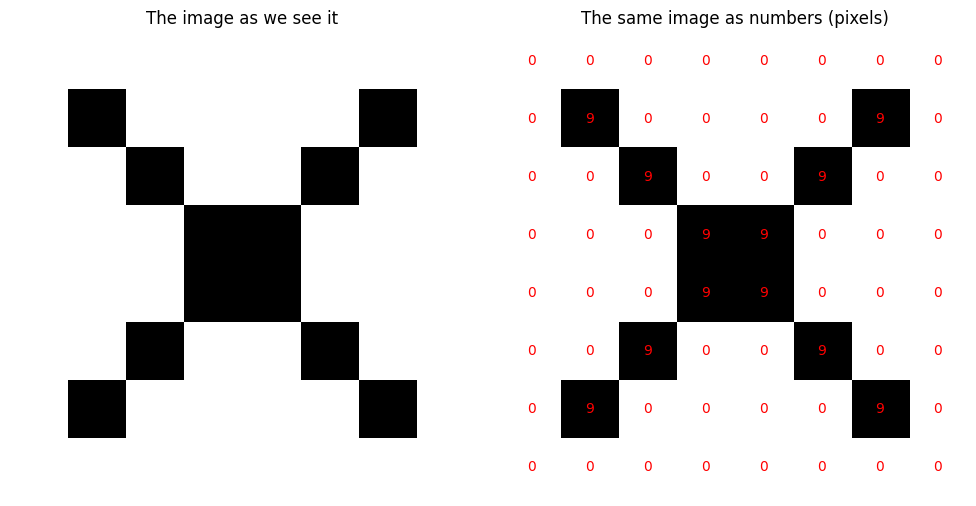

Array shape (Height, Width): (8, 8)


In [1]:
# Import the libraries needed for plotting and computation
import numpy as np
import matplotlib.pyplot as plt

# Create a small 8x8 grayscale "image" representing a simple shape (e.g. the letter X)
img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 9, 0, 0, 0, 0, 9, 0],
    [0, 0, 9, 0, 0, 9, 0, 0],
    [0, 0, 0, 9, 9, 0, 0, 0],
    [0, 0, 0, 9, 9, 0, 0, 0],
    [0, 0, 9, 0, 0, 9, 0, 0],
    [0, 9, 0, 0, 0, 0, 9, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# Draw the image next to its numeric values to show that an image = numbers
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img, cmap='gray_r')          # show the image
ax[0].set_title("The image as we see it")
ax[0].axis('off')

ax[1].imshow(img, cmap='gray_r')
# Write the numeric value on top of each pixel
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        ax[1].text(j, i, int(img[i, j]), ha='center', va='center', color='red')
ax[1].set_title("The same image as numbers (pixels)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

print("Array shape (Height, Width):", img.shape)


<a id="sec3"></a>
## 3️ The Convolution operation  the heart of the CNN

Convolution means sliding a small window (called a **Kernel** or **Filter**) over the image. At each position we compute the
**element-wise multiplication** between the filter and the underlying image region, then sum the results into a single number.

### The steps
1. Place the filter (e.g. `3×3`) over the top-left corner of the image.
2. Multiply each value in the filter by the corresponding value in the image.
3. Sum all the products → a single number that goes into the **Feature Map**.
4. Slide the filter one step and repeat until the whole image is covered.

### A visual illustration of the operation


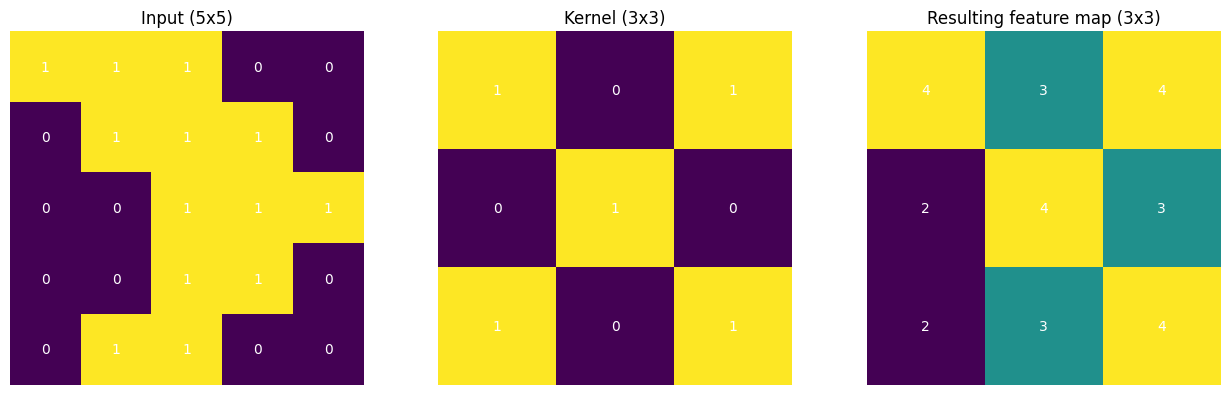

Output size = (3, 3)   (it shrank because we used no padding)


In [2]:
# A visual, step-by-step illustration of the convolution operation
import numpy as np
import matplotlib.pyplot as plt

# 5x5 input matrix
inp = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0],
], dtype=float)

# A 3x3 Kernel that detects a particular pattern
kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
], dtype=float)

def convolve2d(image, k):
    '''A simplified convolution (no padding, stride = 1) for explanation purposes.'''
    kh, kw = k.shape                          # filter dimensions
    oh = image.shape[0] - kh + 1              # output height
    ow = image.shape[1] - kw + 1              # output width
    out = np.zeros((oh, ow))
    for i in range(oh):                       # loop over every possible row
        for j in range(ow):                   # and every possible column
            region = image[i:i+kh, j:j+kw]     # the region covered by the filter
            out[i, j] = np.sum(region * k)     # element-wise multiply, then sum
    return out

feature_map = convolve2d(inp, kernel)

# Show the input + the filter + the resulting feature map
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, data, title in zip(
        ax,
        [inp, kernel, feature_map],
        ["Input (5x5)", "Kernel (3x3)", "Resulting feature map (3x3)"]):
    a.imshow(data, cmap='viridis')
    a.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            a.text(j, i, f"{data[i,j]:.0f}", ha='center', va='center', color='white')
    a.axis('off')
plt.tight_layout()
plt.show()

print("Output size =", feature_map.shape, "  (it shrank because we used no padding)")


###  The output-size formula
When applying a filter, the output dimensions are computed by:

$$ O = \frac{W - K + 2P}{S} + 1 $$

where:
- `W` = input size (width or height).
- `K` = kernel size.
- `P` = padding.
- `S` = stride.

We will explain `P` and `S` shortly.


<a id="sec4"></a>
## 4️ Filters / Kernels in practice

Each filter specializes in detecting a particular **pattern**. In real networks **we do not write the filter values by hand** — the
network **learns them automatically** during training. But to understand the idea, here are some famous hand-crafted edge-detection filters:


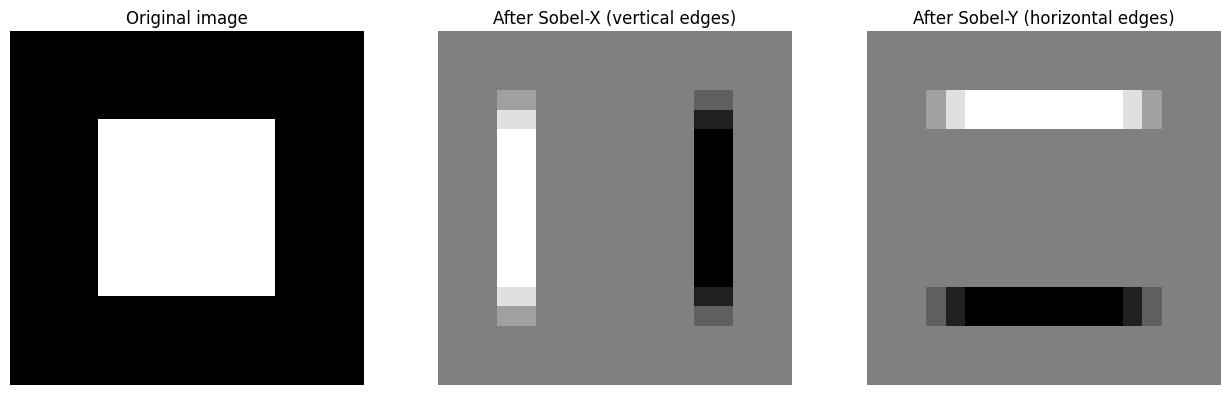

Notice how each filter highlights a different kind of edge!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Build a simple image: a white square on a black background
image = np.zeros((20, 20))
image[5:15, 5:15] = 1.0   # a square in the middle

# Horizontal-edge detection filter (Sobel - X)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)

# Vertical-edge detection filter (Sobel - Y)
sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=float)

def convolve2d(img, k):
    kh, kw = k.shape
    out = np.zeros((img.shape[0]-kh+1, img.shape[1]-kw+1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(img[i:i+kh, j:j+kw] * k)
    return out

edges_x = convolve2d(image, sobel_x)   # vertical edges will appear
edges_y = convolve2d(image, sobel_y)   # horizontal edges will appear

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(image, cmap='gray');   ax[0].set_title("Original image");                  ax[0].axis('off')
ax[1].imshow(edges_x, cmap='gray'); ax[1].set_title("After Sobel-X (vertical edges)");  ax[1].axis('off')
ax[2].imshow(edges_y, cmap='gray'); ax[2].set_title("After Sobel-Y (horizontal edges)"); ax[2].axis('off')
plt.tight_layout()
plt.show()

print("Notice how each filter highlights a different kind of edge!")


> 💡 **The key idea:** the early layers in a CNN learn simple filters (edges and colors),
> while deeper layers combine these features to form more complex patterns (eyes, wheels, faces...).


<a id="sec5"></a>
## 5️ Padding and Stride

###  Padding
We saw that convolution shrinks the image, and that edge pixels are used less often than center pixels.
The fix: add a border of zeros around the image before convolving.

- `padding=0` ← called **"valid"**: no padding, the output is smaller.
- appropriate `padding` ← called **"same"**: the output has the same size as the input.

###  Stride
This is how far the filter moves at each step:
- `stride=1` ← move one pixel (finer detail, larger output).
- `stride=2` ← jump two pixels (smaller output, faster computation, reduces dimensions).

The figure below shows the effect of padding:


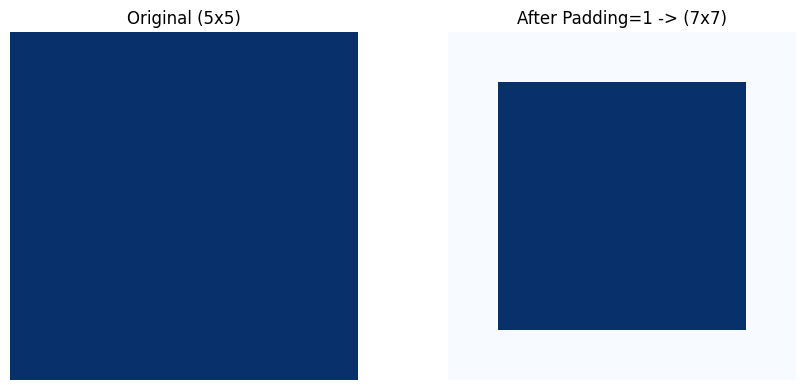

Before padding: (5, 5) -> after padding: (7, 7)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

original = np.ones((5, 5))                 # a 5x5 image

# Apply padding of 1 (a border of zeros around the image)
padded = np.pad(original, pad_width=1, mode='constant', constant_values=0)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(original, cmap='Blues', vmin=0, vmax=1)
ax[0].set_title("Original (5x5)"); ax[0].axis('off')

ax[1].imshow(padded, cmap='Blues', vmin=0, vmax=1)
ax[1].set_title("After Padding=1 -> (7x7)"); ax[1].axis('off')
plt.tight_layout()
plt.show()

print("Before padding:", original.shape, "-> after padding:", padded.shape)


<a id="sec6"></a>
## 6️ The ReLU activation function

After each convolution layer we apply a **non-linear activation function** to enable the network to learn complex relationships.
The most common one in CNNs is **ReLU (Rectified Linear Unit)**:

$$ \text{ReLU}(x) = \max(0, x) $$

Simply: it keeps positive values as they are, and turns negative values into zero.

**Why ReLU?** It is fast to compute and mitigates the *vanishing gradient* problem.


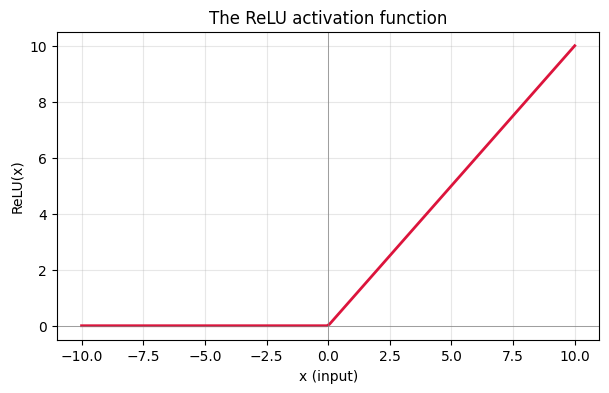

ReLU(-5) = 0  | ReLU(7) = 7


In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)
relu = np.maximum(0, x)            # definition of ReLU

plt.figure(figsize=(7, 4))
plt.plot(x, relu, linewidth=2, color='crimson')
plt.title("The ReLU activation function")
plt.xlabel("x (input)"); plt.ylabel("ReLU(x)")
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.grid(alpha=0.3)
plt.show()

print("ReLU(-5) =", max(0, -5), " | ReLU(7) =", max(0, 7))


<a id="sec7"></a>
## 7️ The Pooling layer

Pooling is used to **reduce the dimensions** of feature maps → fewer computations and less overfitting,
while keeping the most important information. The most common type is **Max Pooling**: take the maximum value from each window.

Example of a `2×2` window with stride `2`: it halves the dimensions.


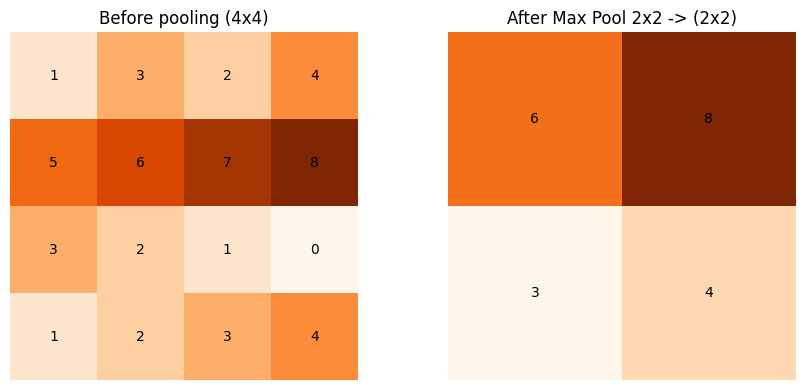

In [6]:
import numpy as np
import matplotlib.pyplot as plt

feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [3, 2, 1, 0],
    [1, 2, 3, 4],
], dtype=float)

def max_pool_2x2(fm):
    '''Max pooling with a 2x2 window and stride 2.'''
    out = np.zeros((fm.shape[0]//2, fm.shape[1]//2))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            window = fm[i*2:i*2+2, j*2:j*2+2]   # a 2x2 window
            out[i, j] = np.max(window)          # take the maximum value
    return out

pooled = max_pool_2x2(feature_map)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, data, title in zip(ax, [feature_map, pooled],
                          ["Before pooling (4x4)", "After Max Pool 2x2 -> (2x2)"]):
    a.imshow(data, cmap='Oranges')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            a.text(j, i, f"{data[i,j]:.0f}", ha='center', va='center')
    a.set_title(title); a.axis('off')
plt.tight_layout()
plt.show()


<a id="sec8"></a>
## 8️ The full CNN architecture

A typical CNN consists of repeating the following blocks, followed by classification layers at the end:

```
Input (image)
   │
   ▼
[ Conv → ReLU → Pool ]   ← feature-extraction block 1 (low-level features: edges)
   │
   ▼
[ Conv → ReLU → Pool ]   ← feature-extraction block 2 (more complex features: shapes)
   │
   ▼
   Flatten               ← flatten the feature maps into a single vector
   │
   ▼
[ Fully Connected → ReLU ]   ← combine the features
   │
   ▼
[ Fully Connected (Output) ] ← number of neurons = number of classes
   │
   ▼
   Softmax → probabilities for each class
```

**The mental rule:**
- The convolutional part (Conv + Pool) = the **Feature Extractor**.
- The fully connected part (FC) = the **Classifier**.

Let's draw this diagram programmatically:


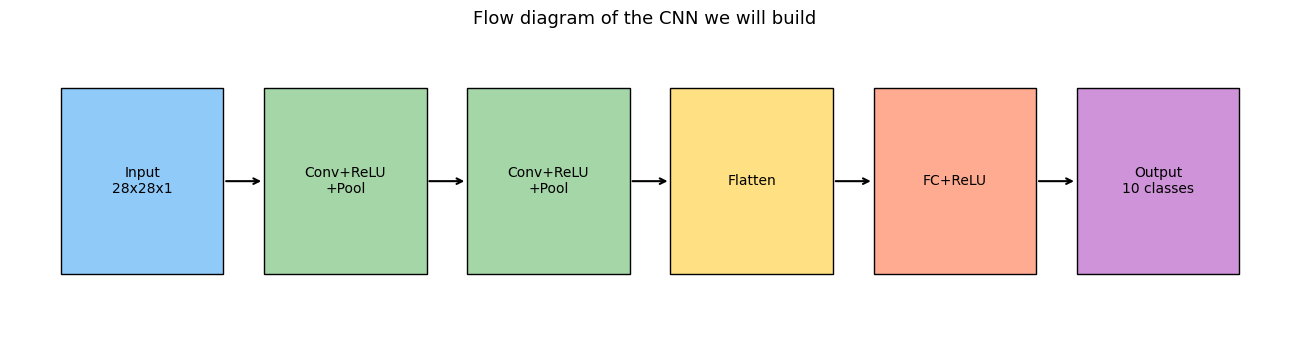

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(13, 3.5))
stages = [
    ("Input\n28x28x1", "#90caf9"),
    ("Conv+ReLU\n+Pool", "#a5d6a7"),
    ("Conv+ReLU\n+Pool", "#a5d6a7"),
    ("Flatten", "#ffe082"),
    ("FC+ReLU", "#ffab91"),
    ("Output\n10 classes", "#ce93d8"),
]
x = 0
for label, color in stages:
    ax.add_patch(patches.Rectangle((x, 0), 1.6, 1, facecolor=color, edgecolor='black'))
    ax.text(x + 0.8, 0.5, label, ha='center', va='center', fontsize=10)
    if x > 0:
        ax.annotate("", xy=(x, 0.5), xytext=(x-0.4, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.5))
    x += 2.0

ax.set_xlim(-0.5, x); ax.set_ylim(-0.3, 1.3)
ax.axis('off')
ax.set_title("Flow diagram of the CNN we will build", fontsize=13)
plt.tight_layout()
plt.show()


<a id="sec9"></a>
## 9️ Hands-on with PyTorch — Setup

Now we move to the actual implementation. We will build a CNN to classify handwritten digits (0-9) from the **MNIST** dataset.

> **Requirements:** if the libraries are not installed, remove the `#` from the following line and run the cell.


In [8]:
# Install the libraries if needed (uncomment when required)
# !pip install torch torchvision matplotlib

# Import the core libraries
import torch                                  # the core library
import torch.nn as nn                         # network building blocks (layers)
import torch.nn.functional as F               # functions (activations, losses...)
import torch.optim as optim                   # optimization algorithms (optimizers)
from torchvision import datasets, transforms  # datasets and image transforms
from torch.utils.data import DataLoader       # for loading data in batches
import matplotlib.pyplot as plt

# Select the device: GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)
print("PyTorch version:", torch.__version__)

# Fix the random seed for reproducible results
torch.manual_seed(42)


Device in use: cpu
PyTorch version: 2.12.0+cpu


<a id="sec10"></a>
##  Loading the MNIST data

- **MNIST**: 70,000 grayscale images of handwritten digits, each of size `28×28`.
- 60,000 images for training + 10,000 for testing.

We apply two transforms to each image:
1. `ToTensor()` — converts the image to a Tensor and scales the values into the range `[0, 1]`.
2. `Normalize()` — standardizes the values (mean ≈ 0) to speed up and stabilize training.


In [9]:
# The chain of transforms applied to every image
transform = transforms.Compose([
    transforms.ToTensor(),                       # image -> Tensor with values in [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),  # standardize with MNIST's known mean & std
])

# Load the training and test sets (downloaded automatically the first time)
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader splits the data into batches and shuffles it
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print("Number of training images:", len(train_dataset))
print("Number of test images:", len(test_dataset))


100.0%
100.0%
100.0%
100.0%

Number of training images: 60000
Number of test images: 10000


###  Let's take a look at some images before training

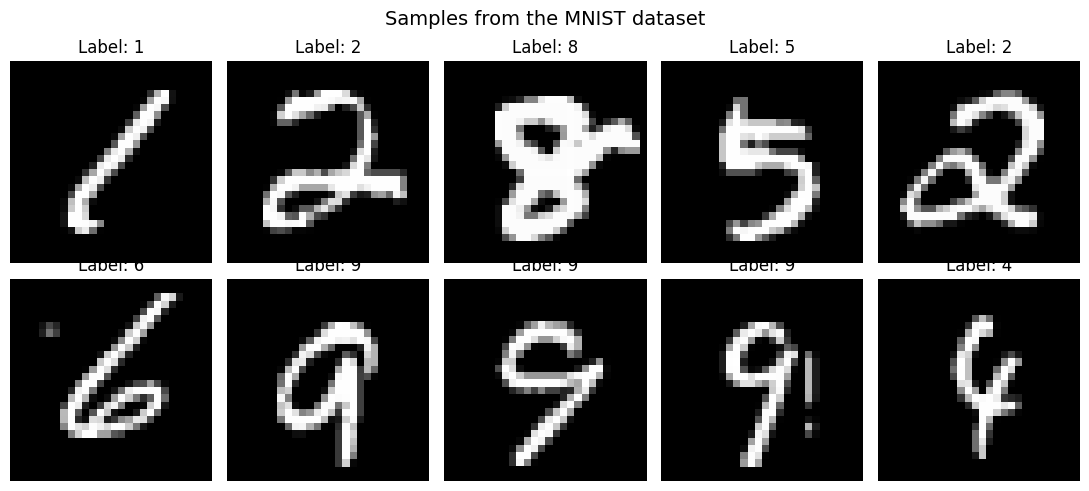

Shape of an image batch (N, C, H, W): torch.Size([64, 1, 28, 28])


In [10]:
# Grab a single batch to display
examples = enumerate(train_loader)
_, (example_images, example_labels) = next(examples)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(example_images[i][0], cmap='gray')   # [0] because there is one channel
    ax.set_title(f"Label: {example_labels[i].item()}")
    ax.axis('off')
plt.suptitle("Samples from the MNIST dataset", fontsize=14)
plt.tight_layout()
plt.show()

print("Shape of an image batch (N, C, H, W):", example_images.shape)


<a id="sec11"></a>
## 1️1️ Defining the CNN model

We build the network by subclassing `nn.Module`. The architecture:

| Layer | Details | Output shape |
|-------|---------|--------------|
| Input | grayscale image | `(1, 28, 28)` |
| Conv1 | 32 filters, size 3×3, padding=1 | `(32, 28, 28)` |
| ReLU + MaxPool 2×2 | — | `(32, 14, 14)` |
| Conv2 | 64 filters, size 3×3, padding=1 | `(64, 14, 14)` |
| ReLU + MaxPool 2×2 | — | `(64, 7, 7)` |
| Flatten | — | `(64×7×7 = 3136)` |
| FC1 | 128 neurons + ReLU | `(128)` |
| Dropout | drop 25% to prevent overfitting | `(128)` |
| FC2 (Output) | 10 neurons (for digits 0-9) | `(10)` |


In [11]:
class SimpleCNN(nn.Module):
    '''A simple CNN for classifying MNIST digits.'''

    def __init__(self):
        super().__init__()
        # First convolution layer: 1 input channel -> 32 feature maps
        # kernel_size=3 with padding=1 keeps the dimensions (same convolution)
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)

        # Second convolution layer: 32 -> 64 feature maps
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Max pooling layer with a 2x2 window (halves the dimensions)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers (the classifier)
        # After two pooling layers: 28->14->7, and 64 channels => 64*7*7 = 3136
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)         # 10 outputs = number of classes

        # Dropout to randomly turn off 25% of neurons during training (reduces overfitting)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # x: (N, 1, 28, 28)
        x = self.pool(F.relu(self.conv1(x)))  # Conv1->ReLU->Pool => (N, 32, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))  # Conv2->ReLU->Pool => (N, 64, 7, 7)

        x = torch.flatten(x, start_dim=1)     # flatten (keep the batch dim) => (N, 3136)

        x = F.relu(self.fc1(x))               # fully connected + ReLU => (N, 128)
        x = self.dropout(x)                   # dropout
        x = self.fc2(x)                        # output layer => (N, 10)
        return x                               # return the raw values (logits)


# Create the model and move it to the device
model = SimpleCNN().to(device)
print(model)

# Count the trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNumber of trainable parameters: {total_params:,}")


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

Number of trainable parameters: 421,642


<a id="sec12"></a>
## 1️2️ The training loop

We need two components:
- **Loss function:** `CrossEntropyLoss` — suitable for multi-class classification (it internally combines Softmax + Log Loss).
- **Optimizer:** `Adam` — updates the weights to minimize the loss.

**Steps for each batch:**
1. Forward pass to get the predictions.
2. Compute the loss.
3. Zero the gradients with `zero_grad()`.
4. Backward pass `loss.backward()` to compute the gradients.
5. Update the weights with `optimizer.step()`.


In [12]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(epoch):
    '''Train the model for one epoch over the entire training set.'''
    model.train()                              # training mode (enables Dropout)
    running_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                  # 1) zero the previous gradients
        outputs = model(images)                # 2) forward pass
        loss = criterion(outputs, labels)      # 3) compute the loss
        loss.backward()                        # 4) backward pass (compute gradients)
        optimizer.step()                       # 5) update the weights

        running_loss += loss.item()
        # Print progress every 200 batches
        if batch_idx % 200 == 0:
            print(f"  Epoch {epoch} | Batch {batch_idx:4d}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")
    return running_loss / len(train_loader)


In [13]:
# Run training for several epochs
num_epochs = 3                                 # 3 epochs are enough for high accuracy on MNIST
loss_history = []

for epoch in range(1, num_epochs + 1):
    print(f"\n===== Epoch {epoch}/{num_epochs} =====")
    avg_loss = train_one_epoch(epoch)
    loss_history.append(avg_loss)
    print(f"   Average loss for epoch {epoch}: {avg_loss:.4f}")

print("\n Training finished!")



===== Epoch 1/3 =====
  Epoch 1 | Batch    0/938 | Loss: 2.3003
  Epoch 1 | Batch  200/938 | Loss: 0.2716
  Epoch 1 | Batch  400/938 | Loss: 0.0345
  Epoch 1 | Batch  600/938 | Loss: 0.0809
  Epoch 1 | Batch  800/938 | Loss: 0.0583
   Average loss for epoch 1: 0.1637

===== Epoch 2/3 =====
  Epoch 2 | Batch    0/938 | Loss: 0.0489
  Epoch 2 | Batch  200/938 | Loss: 0.0936
  Epoch 2 | Batch  400/938 | Loss: 0.0258
  Epoch 2 | Batch  600/938 | Loss: 0.1101
  Epoch 2 | Batch  800/938 | Loss: 0.0268
   Average loss for epoch 2: 0.0561

===== Epoch 3/3 =====
  Epoch 3 | Batch    0/938 | Loss: 0.0093
  Epoch 3 | Batch  200/938 | Loss: 0.0776
  Epoch 3 | Batch  400/938 | Loss: 0.0146
  Epoch 3 | Batch  600/938 | Loss: 0.0326
  Epoch 3 | Batch  800/938 | Loss: 0.0135
   Average loss for epoch 3: 0.0401

 Training finished!


###  The loss curve across epochs

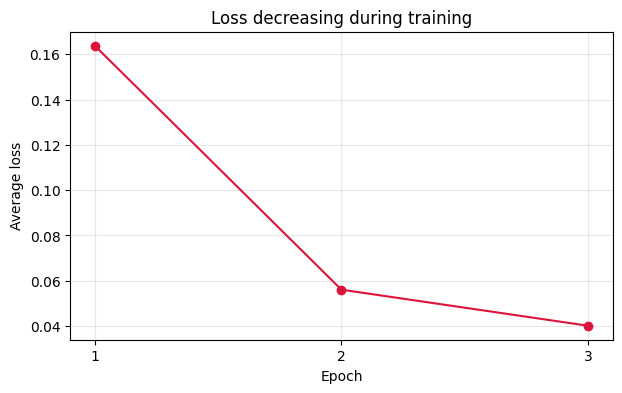

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='crimson')
plt.title("Loss decreasing during training")
plt.xlabel("Epoch"); plt.ylabel("Average loss")
plt.grid(alpha=0.3)
plt.xticks(range(1, num_epochs + 1))
plt.show()


<a id="sec13"></a>
## 1️3️ Evaluation and testing

We measure the model's accuracy on the test data that it **never saw during training**.
We use `model.eval()` and `torch.no_grad()` to disable Dropout and gradient computation (faster and more accurate for evaluation).


In [15]:
def evaluate():
    '''Compute the model's accuracy on the test set.'''
    model.eval()                               # evaluation mode (disables Dropout)
    correct = 0
    total = 0
    with torch.no_grad():                      # no need to compute gradients
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)            # raw predictions (logits)
            _, predicted = torch.max(outputs, dim=1)  # take the class with the highest value
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

acc = evaluate()
print(f" Model accuracy on the test data: {acc:.2f}%")


🎯 Model accuracy on the test data: 99.16%


<a id="sec14"></a>
## 1️4️ Visualizing predictions and feature maps

### a) Show the model's predictions on real images
Green = correct prediction, red = wrong.


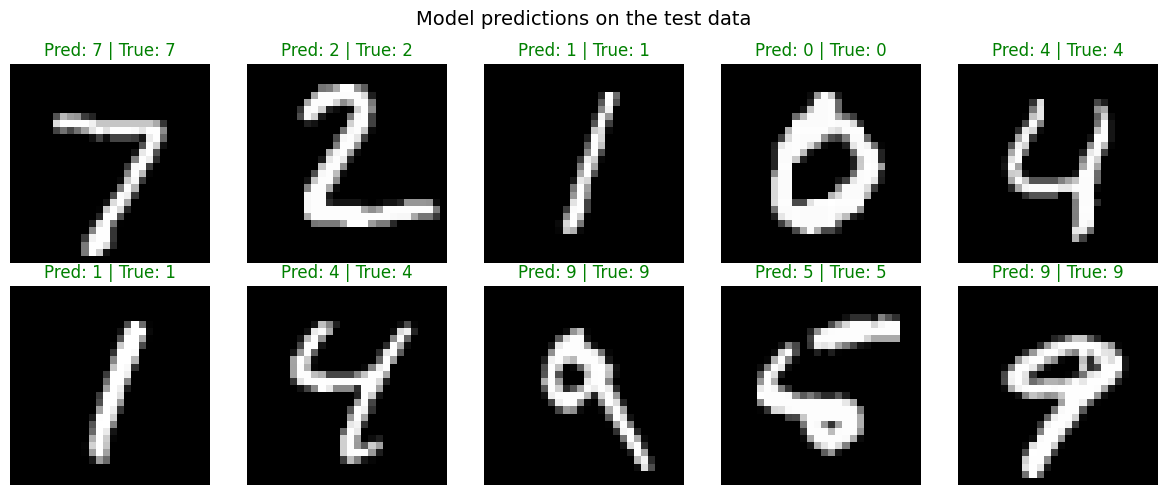

In [16]:
# Grab a batch from the test data
model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)
images_dev = images.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    _, preds = torch.max(outputs, 1)

# Show the first 10 images with prediction vs. ground truth
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i][0], cmap='gray')
    pred = preds[i].item()
    true = labels[i].item()
    color = 'green' if pred == true else 'red'   # color depends on whether the prediction is correct
    ax.set_title(f"Pred: {pred} | True: {true}", color=color)
    ax.axis('off')
plt.suptitle("Model predictions on the test data", fontsize=14)
plt.tight_layout()
plt.show()


### b) What does the network "see"? — Feature Maps
We pass a single image and display the output of the first convolution layer (32 feature maps).
Each map highlights a different pattern detected by one of the learned filters.


Feature maps shape: torch.Size([1, 32, 28, 28])


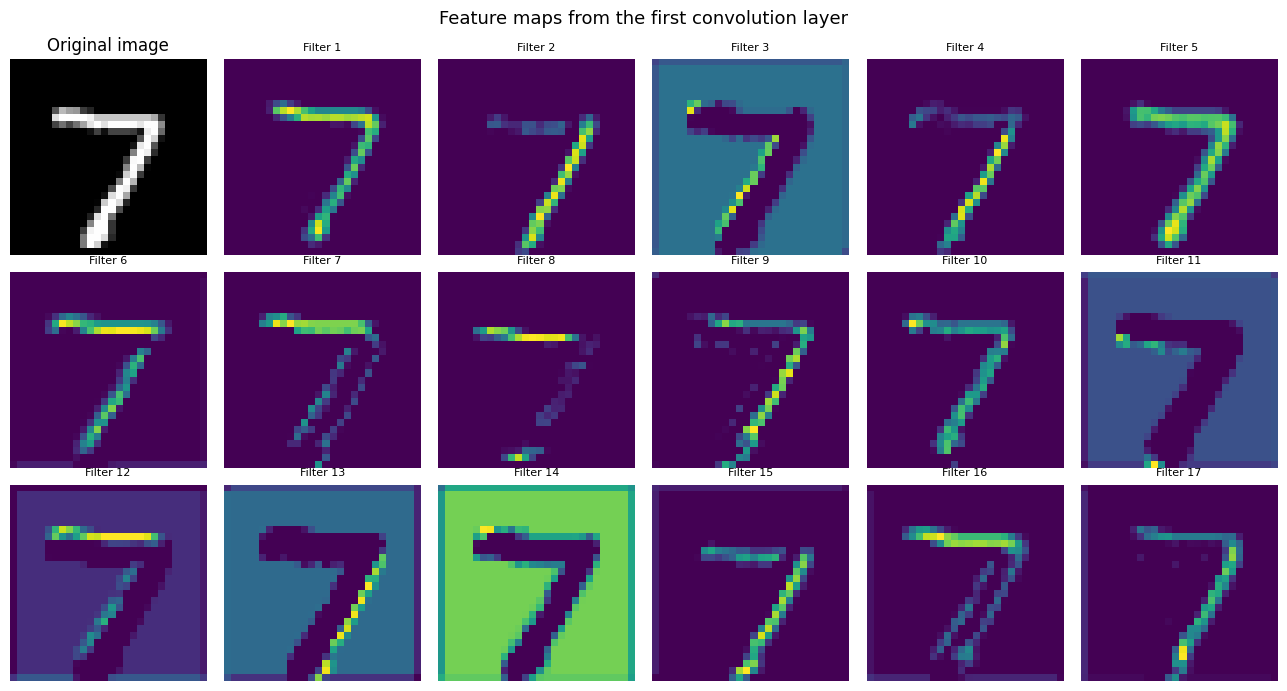

In [17]:
# Take a single image
sample = images[0:1].to(device)   # shape (1, 1, 28, 28)

# Pass it only through the first convolution layer + ReLU
model.eval()
with torch.no_grad():
    fmaps = F.relu(model.conv1(sample))   # (1, 32, 28, 28)

print("Feature maps shape:", fmaps.shape)

# Show the original image, then the first 16 feature maps
fig, axes = plt.subplots(3, 6, figsize=(13, 7))
axes = axes.flat
axes[0].imshow(images[0][0], cmap='gray')
axes[0].set_title("Original image"); axes[0].axis('off')

for i in range(1, 18):
    if i <= fmaps.shape[1]:
        axes[i].imshow(fmaps[0, i-1].cpu(), cmap='viridis')
        axes[i].set_title(f"Filter {i}", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Feature maps from the first convolution layer", fontsize=13)
plt.tight_layout()
plt.show()


### c) Save the trained model
In real projects we save the weights so we can reuse them later without retraining.


In [19]:
# Save only the model's weights (the preferred approach)
torch.save(model.state_dict(), "mnist_cnn.pth")
print(" The model was saved to the file: mnist_cnn.pth")

# How to reload it later:
loaded = SimpleCNN().to(device)
loaded.load_state_dict(torch.load("mnist_cnn.pth"))
loaded.eval()


 The model was saved to the file: mnist_cnn.pth


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

<a id="sec15"></a>
## 1️5️ Summary and ideas for improvement

###  What did we learn?
- **CNNs** solve the huge-dimensionality problem via *local connectivity* and *weight sharing*.
- **Convolution** extracts features by sliding filters over the image.
- **Padding** preserves the dimensions, and **Stride** controls the step size.
- **ReLU** adds non-linearity, and **Pooling** shrinks the dimensions and summarizes information.
- We built a CNN with **PyTorch**, trained it on MNIST, and achieved high accuracy (~99%).
- We learned the **training loop** (forward → loss → backward → step), **evaluation**, and **feature visualization**.

###  Ideas to extend the project
| Idea | Benefit |
|------|---------|
| Try the **CIFAR-10** dataset (color images) | A harder challenge, closer to the real world |
| Add **Batch Normalization** layers | Faster, more stable training |
| Use **Data Augmentation** (rotation/cropping) | Better generalization, resists overfitting |
| Apply **Transfer Learning** (a pre-trained ResNet) | Excellent results with little data |
| Plot a **Confusion Matrix** | Understand where the model makes mistakes |

###  Useful references
- Official PyTorch documentation: https://pytorch.org/tutorials/
- Stanford's CS231n course (CNNs for computer vision): https://cs231n.github.io/

---
